## Entrnamiento de Modelos


--- Comparativa (solo TRAIN con CV) ---

[Logistic Regression]
Accuracy (CV train): 0.9554
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      2870
             Sag       0.91      0.97      0.94      2870
    Sag_Armonico       0.94      0.87      0.90      2870
    Sag_Multiple       0.98      0.96      0.97      2870
       Sag_Notch       0.94      0.97      0.96      2870
Sag_Transitorios       0.96      0.96      0.96      2870

        accuracy                           0.96     17220
       macro avg       0.96      0.96      0.96     17220
    weighted avg       0.96      0.96      0.96     17220


[SVM]
Accuracy (CV train): 0.9739
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      2870
             Sag       0.91      0.99      0.95      2870
    Sag_Armonico       0.99      0.89      0.94      2870
    Sag_Multiple       0.99      0.97      0.98      2870

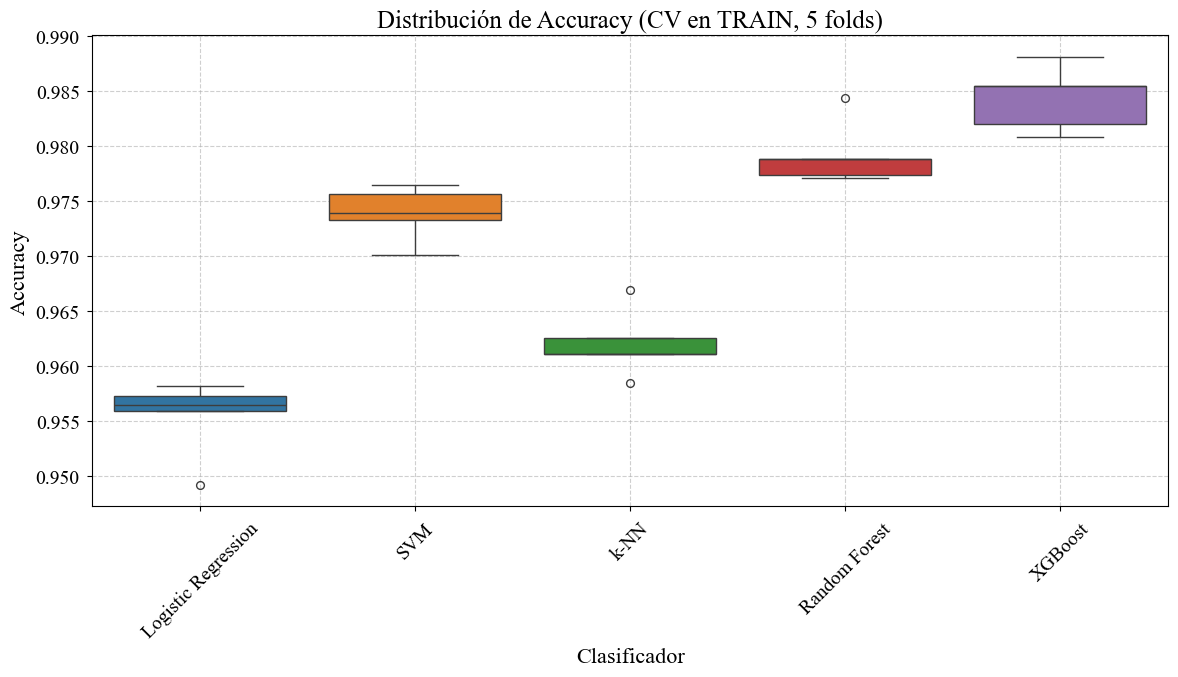

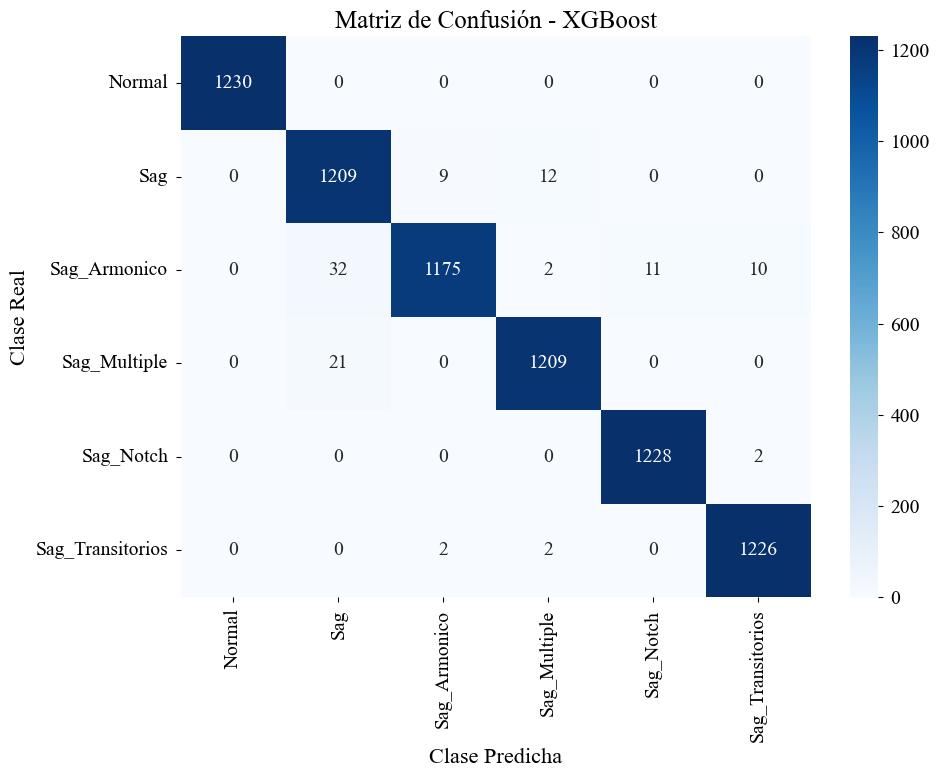

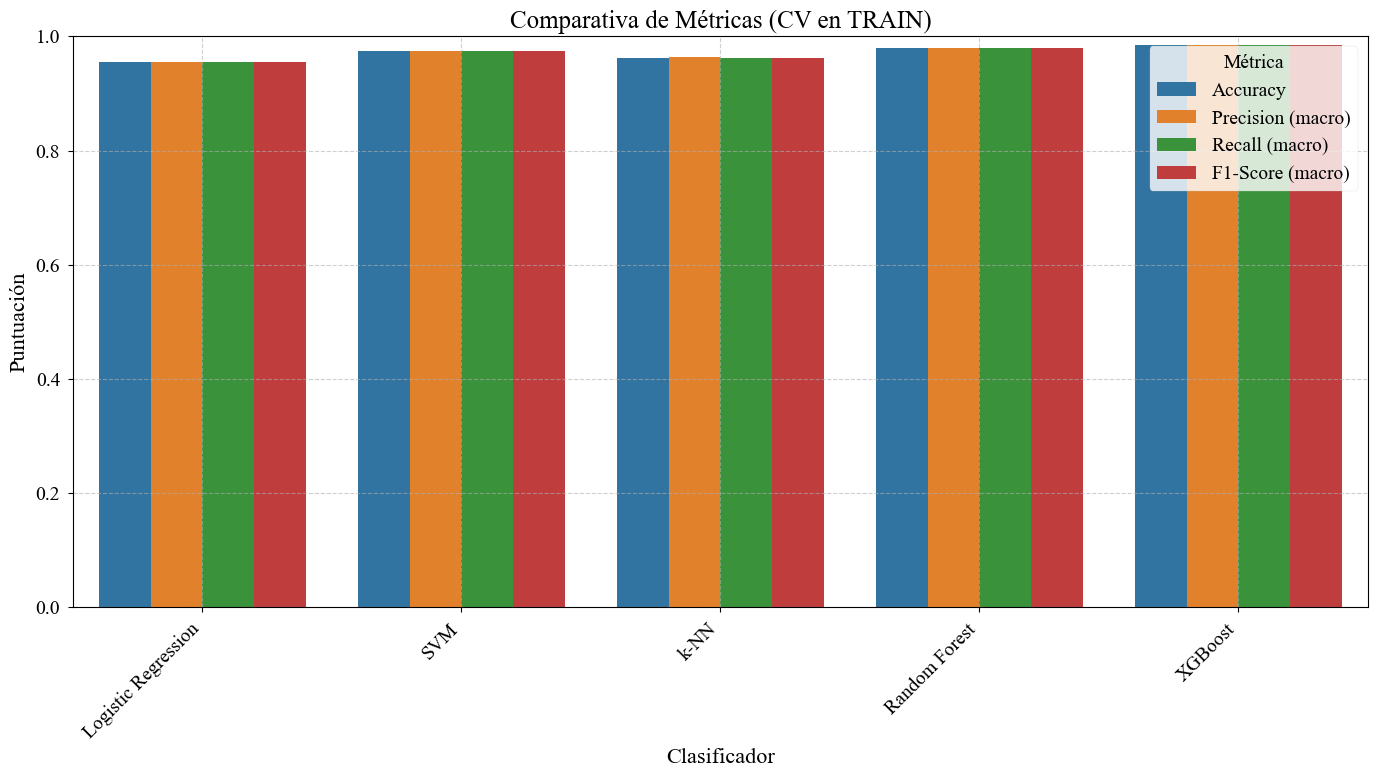

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ---------- Estilo opcional ----------
def _setup_academic_style():
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 14,
        'axes.labelsize': 16, 'axes.titlesize': 18,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'figure.figsize': (10, 6),
        'lines.linewidth': 2
    })

# ---------- Carga ----------
data_path = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df = pd.read_csv(data_path)
X = df.drop(columns=['etiqueta', 'columna_origen', 'duracion_muestras'])
y = df['etiqueta']

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

# ---------- Split primero (evita mirar el test durante selección) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------- Pipelines (sin fuga: scaler dentro) ----------
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
    ]),
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    "Random Forest": Pipeline([
        ('scaler', 'passthrough'),
        ('clf', RandomForestClassifier(
            n_estimators=300, class_weight='balanced_subsample', random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', 'passthrough'),
        ('clf', xgb.XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            num_class=len(np.unique(y_enc)),
            tree_method='hist',
            n_estimators=400,
            random_state=42))
    ])
}

# ---------- Comparativa por CV en TRAIN ----------
_setup_academic_style()
scoring = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted']

print("\n--- Comparativa (solo TRAIN con CV) ---")
results_rows = []
all_accuracies = {}
for name, pipe in models.items():
    # Predicciones CV para reportes macro en TRAIN
    y_pred_cv = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)
    report = classification_report(y_train, y_pred_cv, output_dict=True)
    acc = accuracy_score(y_train, y_pred_cv)

    # Guardar fila resumen
    results_rows.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-Score (macro)': report['macro avg']['f1-score']
    })

    # Distribución de accuracy por fold (para boxplot)
    accs = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    all_accuracies[name] = accs

    print(f"\n[{name}]")
    print(f"Accuracy (CV train): {acc:.4f}")
    print(classification_report(y_train, y_pred_cv, target_names=le.classes_))

results_df = pd.DataFrame(results_rows)
print("\n--- Tabla Resumen (TRAIN CV) ---")
print(results_df.to_string(index=False))

# ---------- Elegir mejor por F1 macro ----------
best_model_name = results_df.sort_values(by='F1-Score (macro)', ascending=False).iloc[0]['Model']
best_pipe = models[best_model_name]

# ---------- Ajuste final en TRAIN y evaluación en TEST ----------
best_pipe.fit(X_train, y_train)
y_test_pred = best_pipe.predict(X_test)

print(f"\n=== Evaluación en TEST con el mejor modelo: {best_model_name} ===")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# ---------- Visualizaciones ----------
# 1) Boxplot accuracies CV (TRAIN)
plt.figure(figsize=(12, 7))
sns.boxplot(data=pd.DataFrame(all_accuracies))
plt.title('Distribución de Accuracy (CV en TRAIN, 5 folds)')
plt.ylabel('Accuracy')
plt.xlabel('Clasificador')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 2) Matriz de confusión en TEST
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

# 3) Barras de métricas (CV en TRAIN)
metrics_to_plot = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_to_plot)
plt.title('Comparativa de Métricas (CV en TRAIN)')
plt.ylabel('Puntuación')
plt.xlabel('Clasificador')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0)
plt.legend(title='Métrica')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [4]:
import joblib

# ---------- Ajuste final en TRAIN y evaluación en TEST ----------
best_pipe.fit(X_train, y_train)
y_test_pred = best_pipe.predict(X_test)

print(f"\n=== Evaluación en TEST con el mejor modelo: {best_model_name} ===")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Asegúrate de que el mejor modelo es el que quieres guardar
if best_model_name == "XGBoost":
    joblib.dump(best_pipe, 'modelo_xgboost.joblib')
    joblib.dump(le, 'label_encoder.joblib')
    joblib.dump(X_train.columns, 'model_columns.joblib')

    print("\n¡Modelo XGBoost, LabelEncoder y columnas del modelo guardados exitosamente!")



=== Evaluación en TEST con el mejor modelo: XGBoost ===
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      1230
             Sag       0.96      0.98      0.97      1230
    Sag_Armonico       0.99      0.96      0.97      1230
    Sag_Multiple       0.99      0.98      0.98      1230
       Sag_Notch       0.99      1.00      0.99      1230
Sag_Transitorios       0.99      1.00      0.99      1230

        accuracy                           0.99      7380
       macro avg       0.99      0.99      0.99      7380
    weighted avg       0.99      0.99      0.99      7380


¡Modelo XGBoost, LabelEncoder y columnas del modelo guardados exitosamente!
